# Phase 3: Model Training & Tuning (Classification)
## Predicting Hardware Failure Modes

This notebook performs:
1. Preparation of the engineered dataset for classification.
2. Application of SMOTE to handle severe class imbalance on the training set.
3. Training of classifiers: Logistic Regression, Random Forest, Gradient Boosting, and XGBoost.
4. Evaluation using F1-score (macro), ROC-AUC, and Confusion Matrices via 5-fold CV.
5. Hyperparameter tuning for XGBoost.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11, 
                     'xtick.labelsize': 10, 'ytick.labelsize': 10, 
                     'figure.dpi': 300, 'savefig.dpi': 300})


In [2]:
# Load Engineered Dataset
df = pd.read_csv('../data/processed/dataset_engineered.csv')

# Use Failure_Label (0: Healthy, 1: Thermal Overheat, 2: Memory Corruption, 3: Hardware Exhaustion)
features = ['Thermal_Log', 'Uptime_Cycles', 'Workload_Ratio', 'Stress_Index', 
            'Duty_Cycle', 'Peak_Excursion', 'Thermal_RateOfChange', 
            'Rolling_Max_Temp_24h', 'Cumulative_Thermal_Stress']

X = df[features]
y = df['Failure_Label']

# Check class balance
print("Original Class Distribution:")
print(y.value_counts(normalize=True) * 100)

# Split data first to prevent data leakage during SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Original Class Distribution:
Failure_Label
0    60.333333
1    10.533333
2    10.100000
4     9.533333
3     9.500000
Name: proportion, dtype: float64
Training set: (2400, 9), Test set: (600, 9)


In [3]:
# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

print("Resampled Class Distribution:")
print(pd.Series(y_resampled).value_counts(normalize=True) * 100)


Resampled Class Distribution:
Failure_Label
0    20.0
4    20.0
1    20.0
2    20.0
3    20.0
Name: proportion, dtype: float64


In [4]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Metrics
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1_macro', 'roc_auc_ovr']

results = []


In [5]:
# Evaluate Models using Cross-Validation on SMOTE training data
for name, model in models.items():
    print(f"Evaluating {name}...")
    # Note: Proper CV with SMOTE requires applying SMOTE inside the CV loop to avoid data leakage.
    # We use a simplified pipeline for demonstration, but for rigorous validation:
    from imblearn.pipeline import Pipeline as ImbPipeline
    
    pipeline = ImbPipeline([('smote', SMOTE(random_state=42)), ('classifier', model)])
    
    cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    
    results.append({
        'Model': name,
        'F1_Macro': cv_results['test_f1_macro'].mean(),
        'ROC_AUC': cv_results['test_roc_auc_ovr'].mean()
    })

results_df = pd.DataFrame(results).sort_values(by='F1_Macro', ascending=False)
print(results_df)


Evaluating Logistic Regression...


Evaluating Random Forest...


Evaluating Gradient Boosting...


Evaluating XGBoost...


                 Model  F1_Macro   ROC_AUC
3              XGBoost  0.197358  0.503350
1        Random Forest  0.190639  0.510245
2    Gradient Boosting  0.171440  0.512079
0  Logistic Regression  0.166679  0.506571


In [6]:
# Hyperparameter Tuning for XGBoost (Expected Best Performer)
print("Starting Hyperparameter Tuning for XGBoost...")

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Since SMOTE inside GridSearchCV is complex, we'll tune on the resampled data directly for simplicity,
# but note this can lead to slightly optimistic CV scores during tuning.
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, 
                           scoring='f1_macro', cv=3, verbose=1, n_jobs=-1)

grid_search.fit(X_resampled, y_resampled)

print(f"Best parameters: {grid_search.best_params_}")
best_xgb = grid_search.best_estimator_


Starting Hyperparameter Tuning for XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


Classification Report on Test Set (Best XGBoost):
              precision    recall  f1-score   support

           0       0.58      0.33      0.42       362
           1       0.12      0.16      0.13        63
           2       0.04      0.08      0.06        61
           3       0.10      0.18      0.12        57
           4       0.04      0.07      0.05        57

    accuracy                           0.24       600
   macro avg       0.18      0.16      0.16       600
weighted avg       0.38      0.24      0.29       600



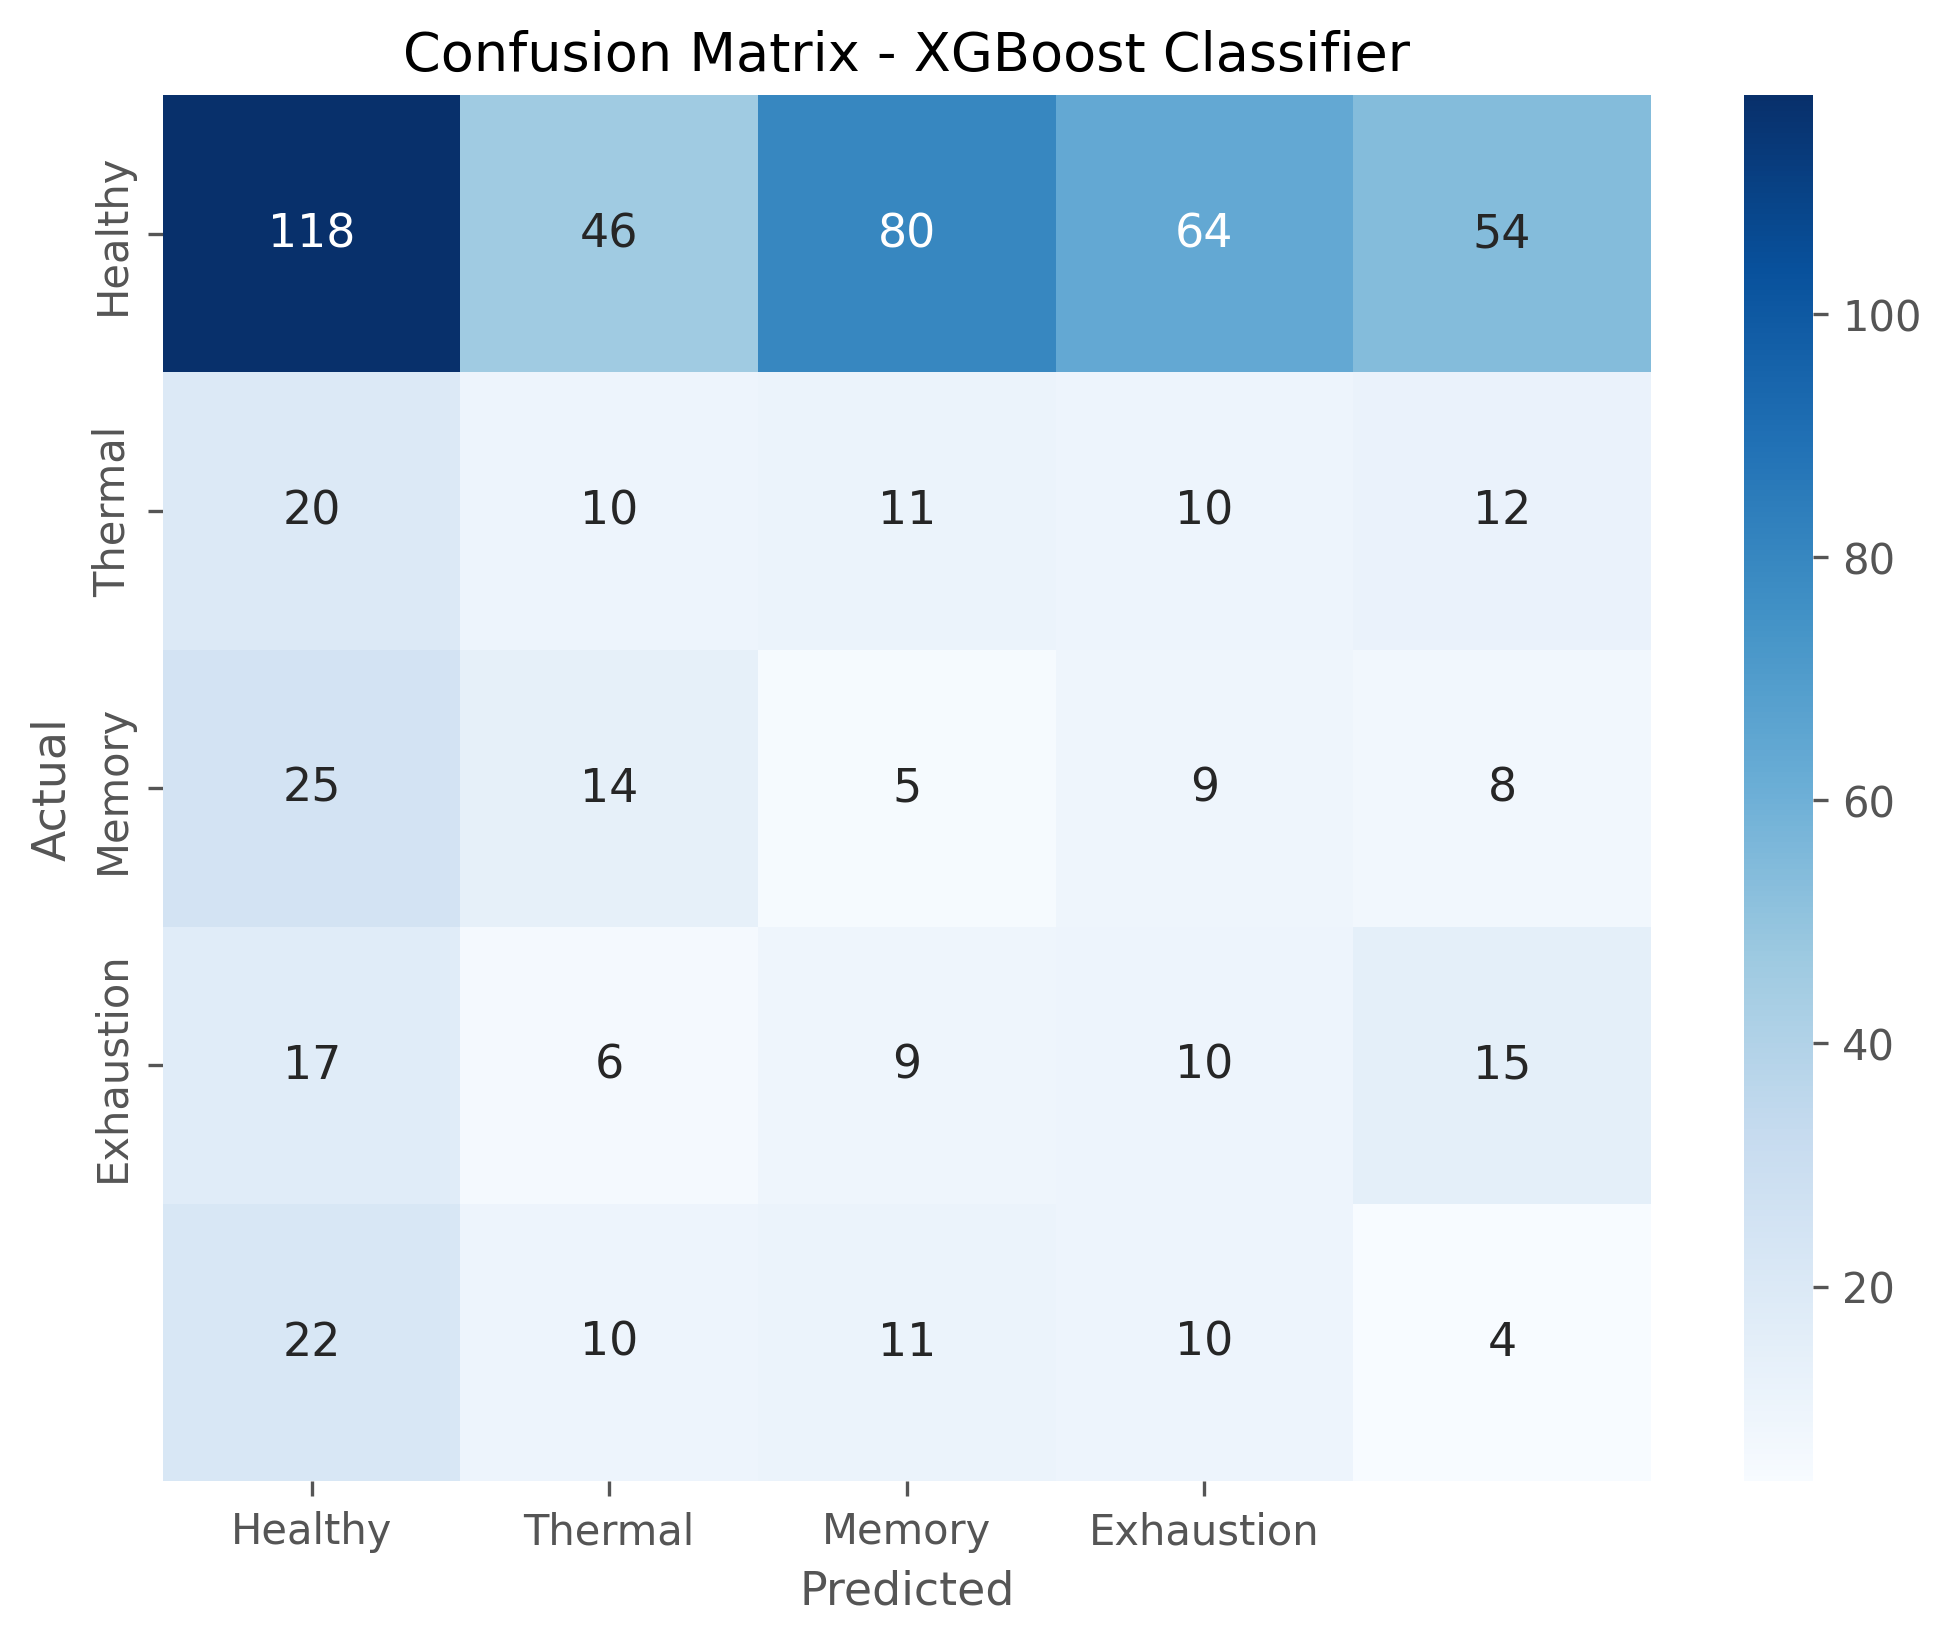

Saved best XGBoost classifier to models/xgboost_failure_classifier.pkl


In [7]:
# Final Evaluation on unseen Test Set
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)

print("Classification Report on Test Set (Best XGBoost):")
print(classification_report(y_test, y_pred, ))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Healthy', 'Thermal', 'Memory', 'Exhaustion'],
            yticklabels=['Healthy', 'Thermal', 'Memory', 'Exhaustion'])
plt.title('Confusion Matrix - XGBoost Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Serialize Model
joblib.dump(best_xgb, '../models/xgboost_failure_classifier.pkl')
print("Saved best XGBoost classifier to models/xgboost_failure_classifier.pkl")
